<a href="https://colab.research.google.com/github/kanika10-hub/CUSTOMER_CHURN_PREDICTION/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [10]:
import os
import pandas as pd
import numpy as np

Define File Paths

In [11]:
RAW_PATH = "raw/customer_churn.csv"
OUTPUT_PATH = "gold/clean_data.csv"

In [12]:
df =pd.read_csv("raw/customer_churn.csv")

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Load Dataset

In [15]:
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(f"File not found at {RAW_PATH}")

df = pd.read_csv(RAW_PATH)

print("[INFO] Data Loaded Successfully")
df.head()

[INFO] Data Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


LOAD RAW DATA + BASIC VIEW (EXTRACT)

In [16]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

Standardize Column Names

In [17]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


INSPECT DATA (UNDERSTANDING PHASE)

In [18]:
print("\n========== [INSPECT] DATA INFO ==========")

print("\nINFO:")
df.info()

print("\nDESCRIBE:")
print(df.describe(include="all"))

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDUPLICATES:")
print(df.duplicated().sum())


========== [INSPECT] DATA INFO ==========

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   objec

CLEAN COLUMN NAMES (TRANSFORM STARTS)

In [19]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("[TRANSFORM] Column names standardized")

[TRANSFORM] Column names standardized


REMOVE DUPLICATES

In [20]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"[TRANSFORM] Removed {before - after} duplicate rows")

[TRANSFORM] Removed 0 duplicate rows


HANDLE MISSING VALUES

In [21]:
for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        # numeric → median (robust to outliers)
        df[col].fillna(df[col].median(), inplace=True)
    else:
        # categorical → mode (most frequent value)
        df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown", inplace=True)

print("[TRANSFORM] Missing values handled")

[TRANSFORM] Missing values handled


/tmp/ipykernel_3532/4029093776.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown", inplace=True)
/tmp/ipykernel_3532/4029093776.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

FIX DATA TYPES

In [22]:
for col in df.columns:
    # convert object → category if low cardinality
    if df[col].dtype == "object":
        if df[col].nunique() < 50:
            df[col] = df[col].astype("category")

    # optimize numeric types
    elif df[col].dtype == "float64":
        df[col] = pd.to_numeric(df[col], downcast="float")
    elif df[col].dtype == "int64":
        df[col] = pd.to_numeric(df[col], downcast="integer")

print("[TRANSFORM] Data types optimized")

[TRANSFORM] Data types optimized


VALIDATION

In [23]:
print("\n========== [VALIDATE] DATA QUALITY CHECK ==========")

# 1. Missing values check
print("\nNull values remaining:")
print(df.isnull().sum().sum())

# 2. Duplicates check
print("\nDuplicates remaining:")
print(df.duplicated().sum())

# 3. Data types check
print("\nData types:")
print(df.dtypes)

# 4. Basic sanity checks (numeric columns)
print("\nNumeric summary:")
print(df.describe())

# Final validation flag
if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\n[VALIDATION PASSED] Data is clean ")
else:
    print("\n[WARNING] Issues still exist ")


========== [VALIDATE] DATA QUALITY CHECK ==========

Null values remaining:
0

Duplicates remaining:
0

Data types:
customerid            object
gender              category
seniorcitizen           int8
partner             category
dependents          category
tenure                  int8
phoneservice        category
multiplelines       category
internetservice     category
onlinesecurity      category
onlinebackup        category
deviceprotection    category
techsupport         category
streamingtv         category
streamingmovies     category
contract            category
paperlessbilling    category
paymentmethod       category
monthlycharges       float32
totalcharges          object
churn               category
dtype: object

Numeric summary:
       seniorcitizen       tenure  monthlycharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761696
std         0.368612    24.559481       30.089973
min         0.000000     0.000000       18

LOAD TO GOLD FOLDER

In [24]:
GOLD_DIR = "gold"
OUTPUT_PATH = "gold/clean_data.csv"

os.makedirs(GOLD_DIR, exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)

print("\n[LOAD] Clean dataset saved successfully")
print("Saved at:", OUTPUT_PATH)
print("Final Shape:", df.shape)


[LOAD] Clean dataset saved successfully
Saved at: gold/clean_data.csv
Final Shape: (7043, 21)


DATABSE AND TABLE CREATION

CREATE SQLITE DATABASE

In [25]:
import sqlite3

# Create database file
conn = sqlite3.connect("customer_churn.db")
cursor = conn.cursor()

In [26]:
df = pd.read_csv("gold/clean_data.csv")

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Check

In [27]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null

Connect SQLite Database

In [28]:
conn = sqlite3.connect("telco_churn.db")
cursor = conn.cursor()

Create Table: customers

In [29]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    customer_id TEXT PRIMARY KEY
);
""")

Create Table: customer_demographics

In [30]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS customer_demographics (
    customer_id TEXT PRIMARY KEY,
    gender TEXT CHECK (gender IN ('Male', 'Female')),
    senior_citizen INTEGER CHECK (senior_citizen IN (0,1)),
    partner TEXT CHECK (partner IN ('Yes','No')),
    dependents TEXT CHECK (dependents IN ('Yes','No')),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

Create Table: service_features

In [31]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS service_features (
    customer_id TEXT PRIMARY KEY,
    phone_service TEXT CHECK (phone_service IN ('Yes','No')),
    multiple_lines TEXT,
    internet_service TEXT,
    online_security TEXT,
    online_backup TEXT,
    device_protection TEXT,
    tech_support TEXT,
    streaming_tv TEXT,
    streaming_movies TEXT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

Create Table: account_details

In [32]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS account_details (
    customer_id TEXT PRIMARY KEY,
    contract TEXT CHECK (contract IN ('Month-to-month','One year','Two year')),
    paperless_billing TEXT CHECK (paperless_billing IN ('Yes','No')),
    payment_method TEXT,
    monthly_charges REAL CHECK (monthly_charges >= 0),
    total_charges REAL CHECK (total_charges >= 0),
    tenure INTEGER CHECK (tenure >= 0),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

Create Table: churn_status

In [33]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS churn_status (
    customer_id TEXT PRIMARY KEY,
    churn TEXT CHECK (churn IN ('Yes','No')),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

In [34]:
print(df.columns)

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')


Insert Data into Tables

In [35]:
for _, row in df.iterrows():
  cid = row["customerid"]

    # customers table
  cursor.execute("INSERT OR IGNORE INTO customers VALUES (?)", (cid,))

    # demographics
  cursor.execute("""
        INSERT OR IGNORE INTO customer_demographics VALUES (?,?,?,?,?)
    """, (
        cid,
        row["gender"],
        row["seniorcitizen"],
        row["partner"],
        row["dependents"]
    ))

    # service features
  cursor.execute("""
        INSERT OR IGNORE INTO service_features VALUES (?,?,?,?,?,?,?,?,?,?)
    """, (
        cid,
        row["phoneservice"],
        row["multiplelines"],
        row["internetservice"],
        row["onlinesecurity"],
        row["onlinebackup"],
        row["deviceprotection"],
        row["techsupport"],
        row["streamingtv"],
        row["streamingmovies"]
    ))

    # account details
  cursor.execute("""
        INSERT OR IGNORE INTO account_details VALUES (?,?,?,?,?,?,?)
    """, (
        cid,
        row["contract"],
        row["paperlessbilling"],
        row["paymentmethod"],
        row["monthlycharges"],
        row["totalcharges"],
        row["tenure"]
    ))

    # churn table
  cursor.execute("""
        INSERT OR IGNORE INTO churn_status VALUES (?,?)
    """, (
        cid,
        row["churn"]
    ))

Commit Changes

In [36]:
conn.commit()

Quick SQL Test Query

In [37]:
pd.read_sql("""
SELECT c.customer_id, d.gender, a.tenure, s.internet_service, ch.churn
FROM customers c
JOIN customer_demographics d ON c.customer_id = d.customer_id
JOIN account_details a ON c.customer_id = a.customer_id
JOIN service_features s ON c.customer_id = s.customer_id
JOIN churn_status ch ON c.customer_id = ch.customer_id
LIMIT 10;
""", conn)

,customer_id,gender,tenure,internet_service,churn
0,7590-VHVEG,Female,1,DSL,No
1,5575-GNVDE,Male,34,DSL,No
2,3668-QPYBK,Male,2,DSL,Yes
3,7795-CFOCW,Male,45,DSL,No
4,9237-HQITU,Female,2,Fiber optic,Yes
5,9305-CDSKC,Female,8,Fiber optic,Yes
6,1452-KIOVK,Male,22,Fiber optic,No
7,6713-OKOMC,Female,10,DSL,No
8,7892-POOKP,Female,28,Fiber optic,Yes
9,6388-TABGU,Male,62,DSL,No


Close Connection

In [38]:
conn.close()

PART-4  Exploratory Data Analysis

4A — Descriptive Statistics   

In [39]:
df = pd.read_csv("/content/gold/clean_data.csv")

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.shape

(7043, 21)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [42]:
df.describe()

,seniorcitizen,tenure,monthlycharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [43]:
df.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [44]:
df.duplicated().sum()

np.int64(0)

In [46]:
# Mean
print("\n========== Mean ==========")
print(df.select_dtypes(include=['int64', 'float64']).mean())

# Median
print("\n========== Median ==========")
print(df.select_dtypes(include=['int64', 'float64']).median())

# Standard Deviation
print("\n========== Standard Deviation ==========")
print(df.select_dtypes(include=['int64', 'float64']).std())

# Minimum
print("\n========== Minimum ==========")
print(df.select_dtypes(include=['int64', 'float64']).min())

# Maximum
print("\n========== Maximum ==========")
print(df.select_dtypes(include=['int64', 'float64']).max())

# Value counts for categorical columns
categorical_cols = df.select_dtypes(include='object').columns


========== Mean ==========
seniorcitizen      0.162147
tenure            32.371149
monthlycharges    64.761692
dtype: float64

========== Median ==========
seniorcitizen      0.00
tenure            29.00
monthlycharges    70.35
dtype: float64

========== Standard Deviation ==========
seniorcitizen      0.368612
tenure            24.559481
monthlycharges    30.090047
dtype: float64

========== Minimum ==========
seniorcitizen      0.00
tenure             0.00
monthlycharges    18.25
dtype: float64

========== Maximum ==========
seniorcitizen       1.00
tenure             72.00
monthlycharges    118.75
dtype: float64


In [47]:

for col in categorical_cols:
    print(f"\n========== {col} ==========")
    print(df[col].value_counts())



========== customerid ==========
customerid
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

========== gender ==========
gender
Male      3555
Female    3488
Name: count, dtype: int64

========== partner ==========
partner
No     3641
Yes    3402
Name: count, dtype: int64

========== dependents ==========
dependents
No     4933
Yes    2110
Name: count, dtype: int64

========== phoneservice ==========
phoneservice
Yes    6361
No      682
Name: count, dtype: int64

========== multiplelines ==========
multiplelines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

========== internetservice ==========
internetservice
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

========== onlinesecurity ==========
onlinesecurity
No               

In [48]:
# Missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

print("\n========== Missing Values ==========")
display(missing)


========== Missing Values ==========


,Missing Count,Missing Percentage
customerid,0,0.0
gender,0,0.0
seniorcitizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure,0,0.0
phoneservice,0,0.0
multiplelines,0,0.0
internetservice,0,0.0
onlinesecurity,0,0.0


Univariate Analysis

Numerical Histograms

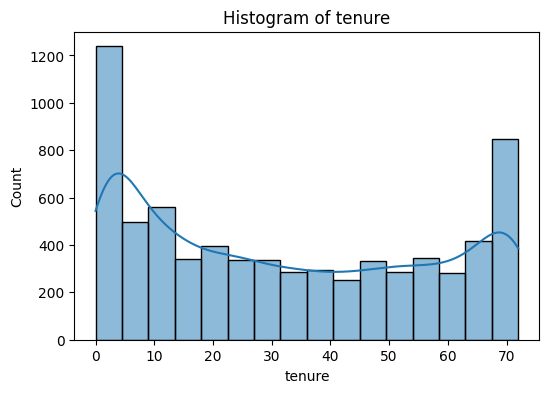

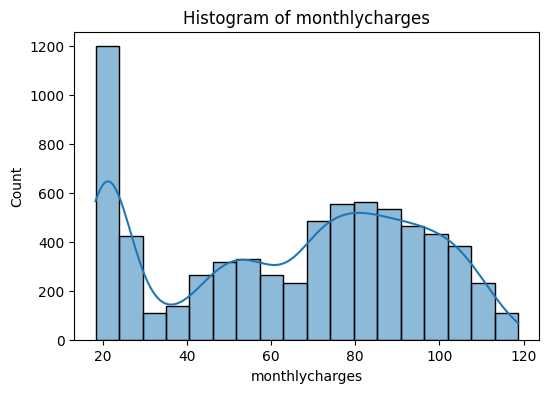

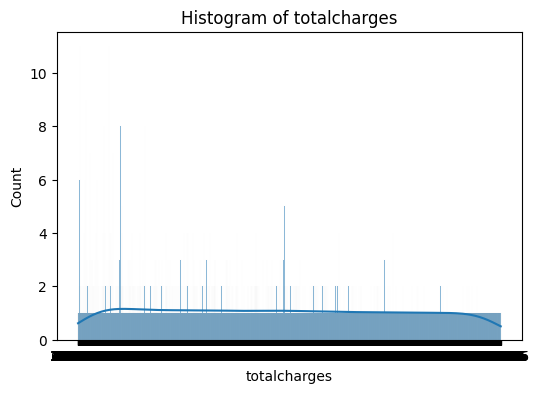

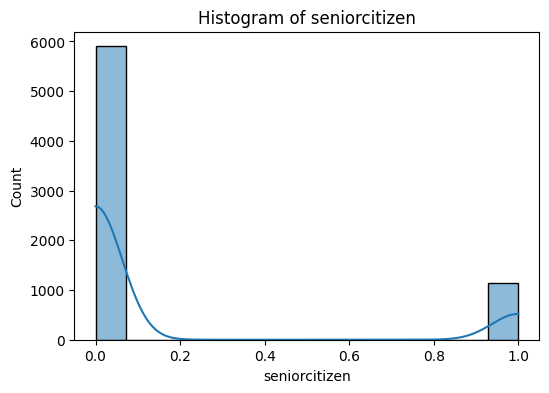

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['tenure', 'monthlycharges', 'totalcharges', 'seniorcitizen']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

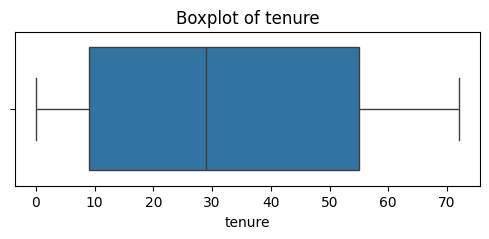

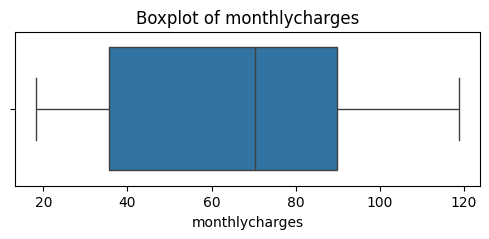

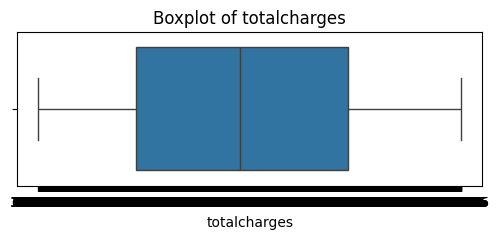

In [53]:
for col in ['tenure','monthlycharges','totalcharges']:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

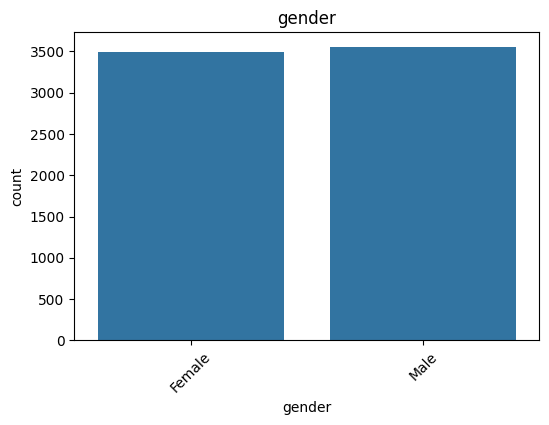

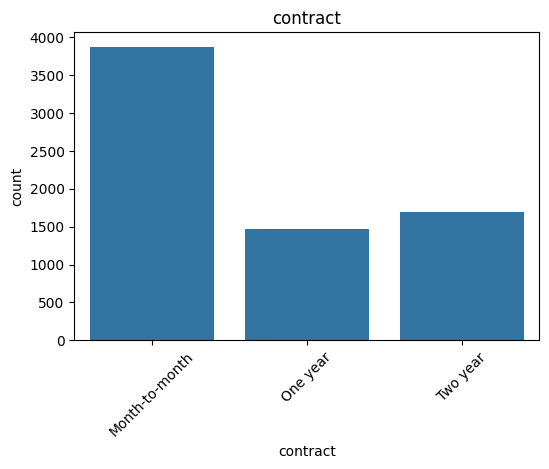

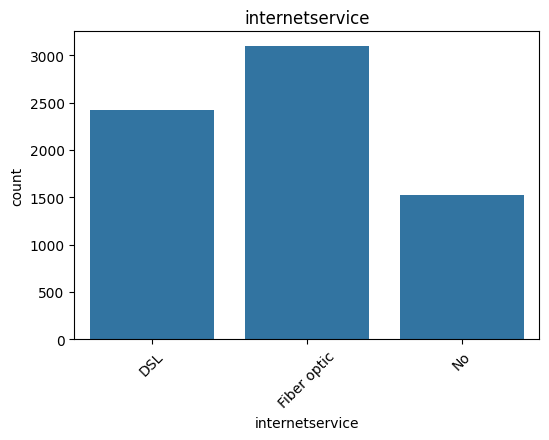

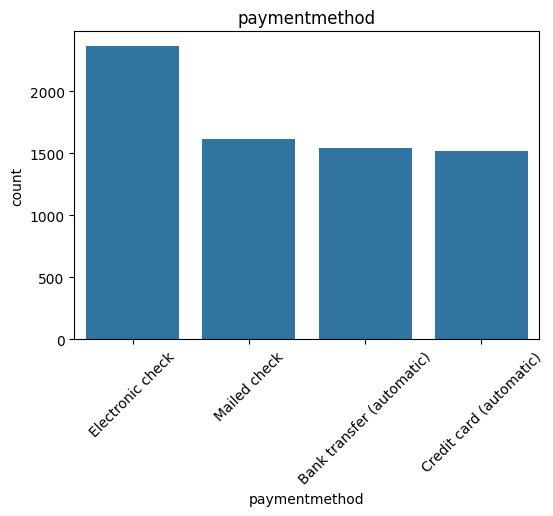

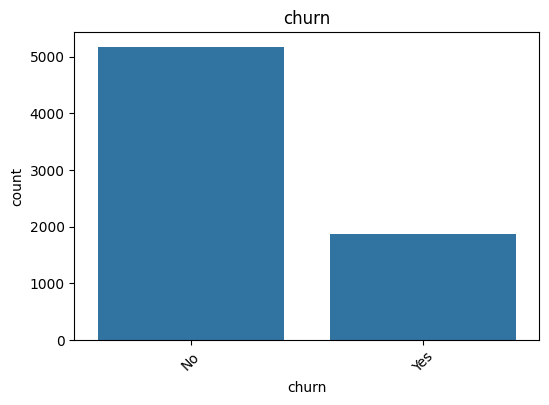

In [52]:
cat_cols = ['gender','contract','internetservice','paymentmethod','churn']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

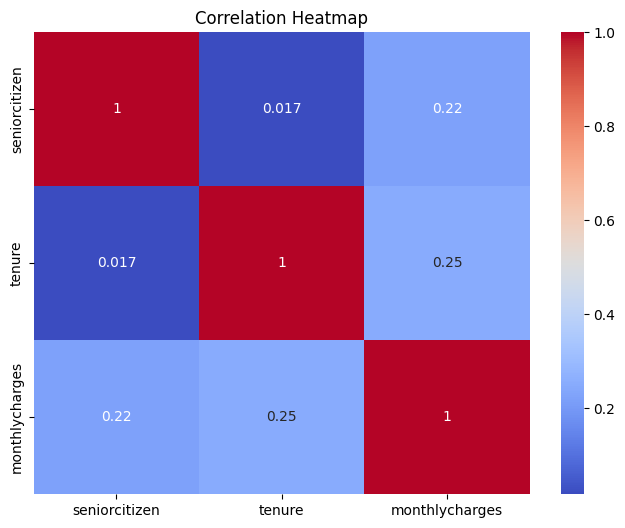

In [54]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

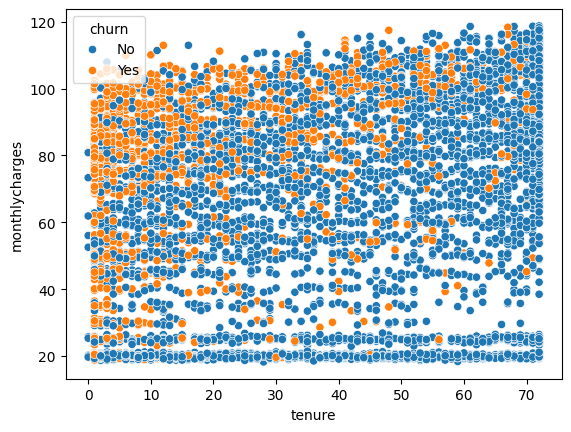

In [56]:
sns.scatterplot(data=df,
                x='tenure',
                y='monthlycharges',
                hue='churn')

plt.show()

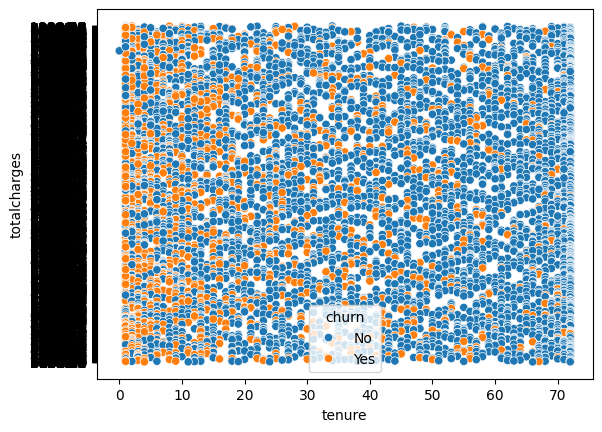

In [58]:
sns.scatterplot(data=df,
                x='tenure',
                y='totalcharges',
                hue='churn')

plt.show()

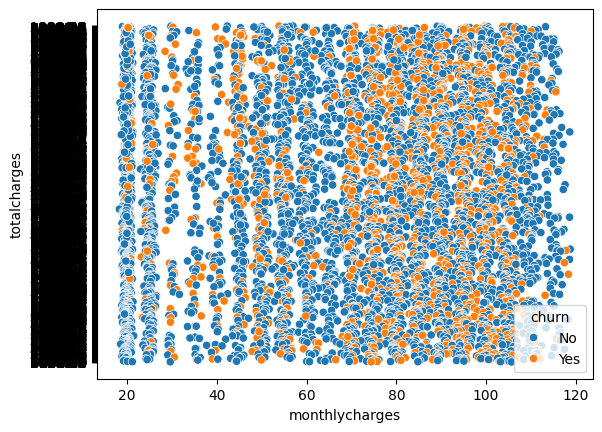

In [59]:
sns.scatterplot(data=df,
                x='monthlycharges',
                y='totalcharges',
                hue='churn')

plt.show()

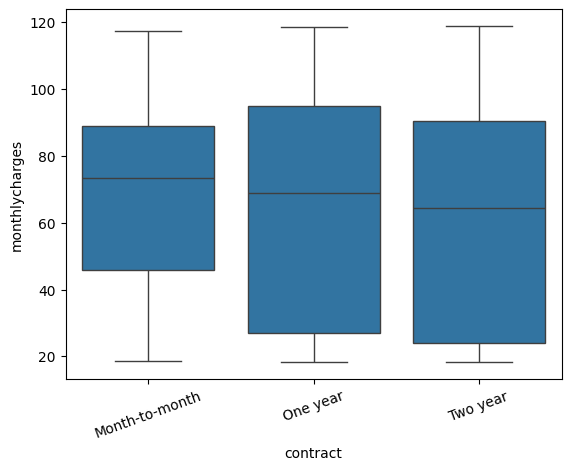

In [60]:
sns.boxplot(data=df,
            x='contract',
            y='monthlycharges')

plt.xticks(rotation=20)
plt.show()

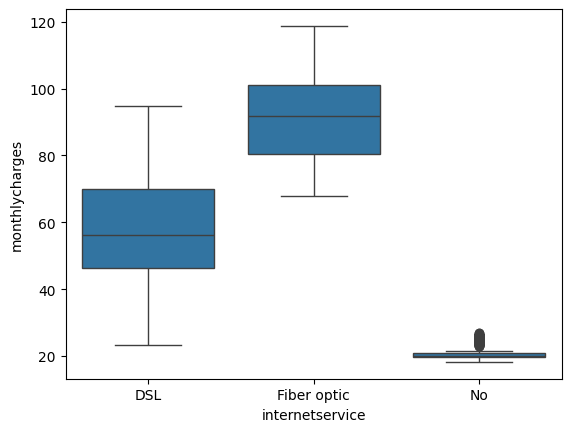

In [61]:
sns.boxplot(data=df,
            x='internetservice',
            y='monthlycharges')

plt.show()

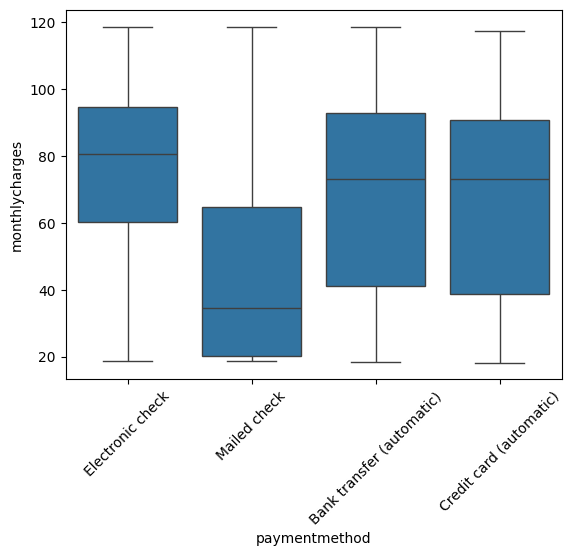

In [62]:
sns.boxplot(data=df,
            x='paymentmethod',
            y='monthlycharges')

plt.xticks(rotation=45)
plt.show()

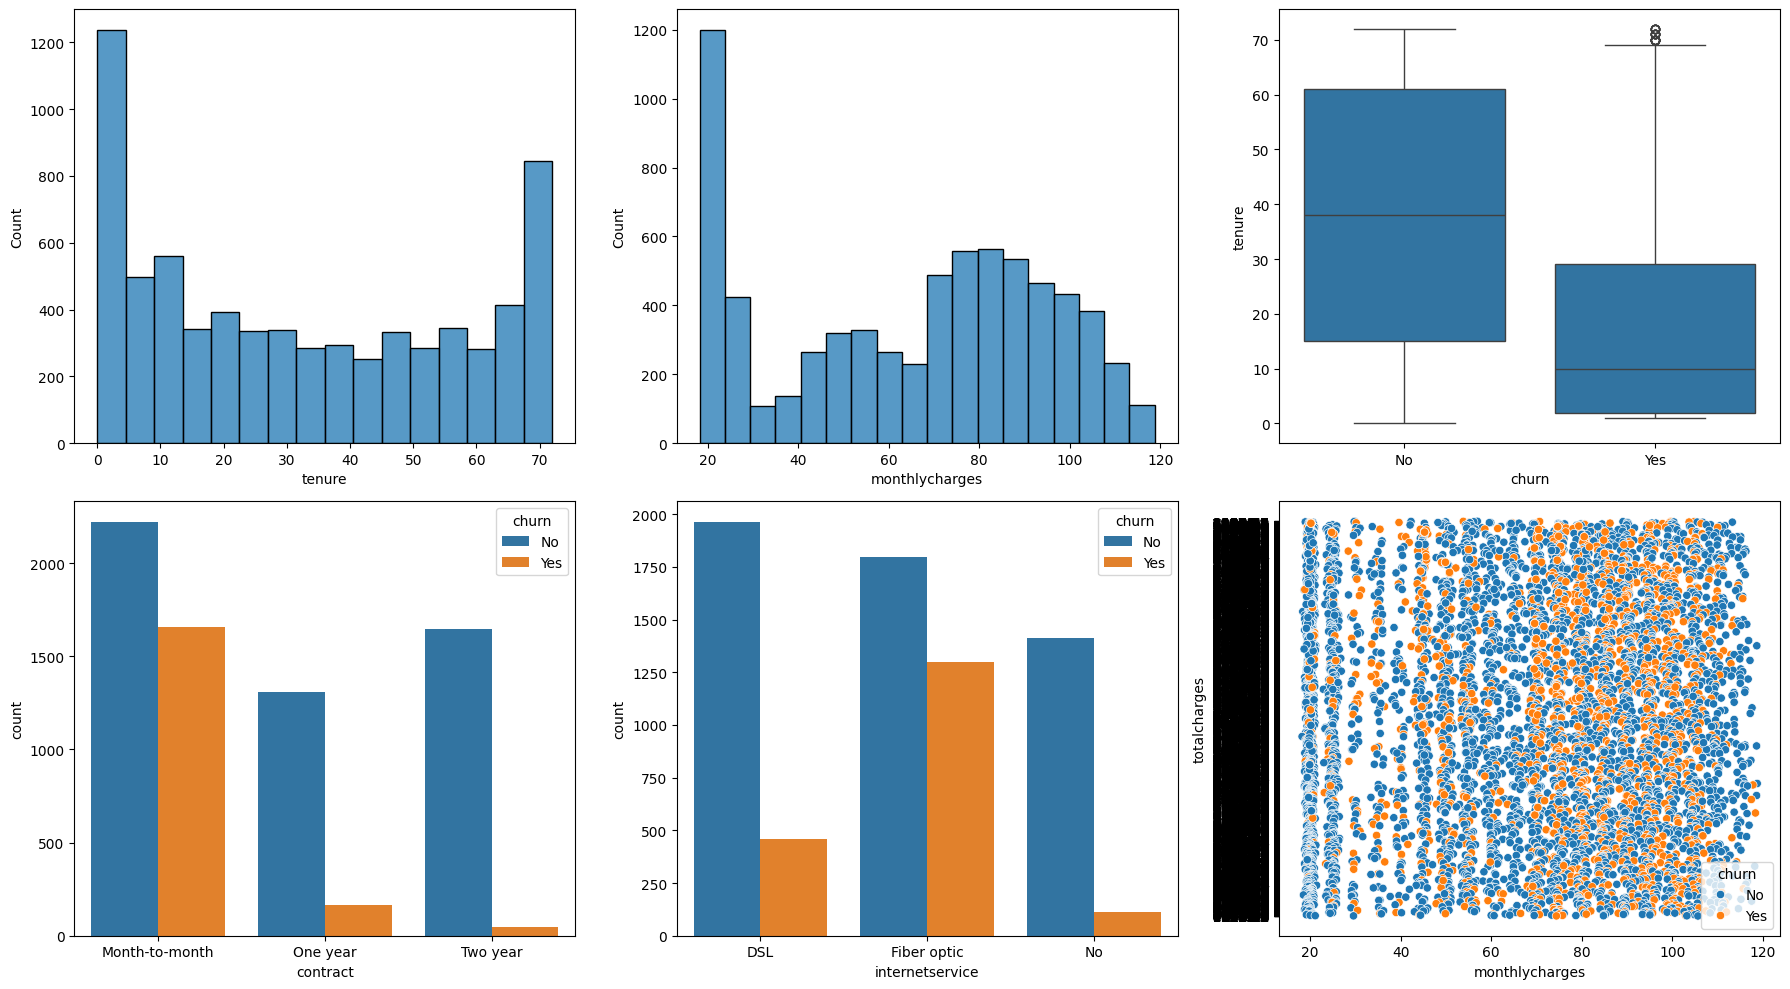

In [64]:
fig, axes = plt.subplots(2,3,figsize=(18,10))

sns.histplot(df['tenure'],ax=axes[0,0])

sns.histplot(df['monthlycharges'],ax=axes[0,1])

sns.boxplot(data=df,x='churn',y='tenure',ax=axes[0,2])

sns.countplot(data=df,x='contract',hue='churn',ax=axes[1,0])

sns.countplot(data=df,x='internetservice',hue='churn',ax=axes[1,1])

sns.scatterplot(data=df,
                x='monthlycharges',
                y='totalcharges',
                hue='churn',
                ax=axes[1,2])

plt.tight_layout()
plt.show()

In [67]:
# Average churn rate by contract type
contract_churn = pd.crosstab(df["contract"], df["churn"], normalize="index") * 100
print(contract_churn)

churn                  No        Yes
contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [69]:
df.groupby("churn")["monthlycharges"].mean()

,monthlycharges
churn,
No,61.265124
Yes,74.441332


In [71]:
df.groupby("churn")["tenure"].mean()

,tenure
churn,
No,37.569965
Yes,17.979133


In [73]:
tech_churn = pd.crosstab(df["techsupport"], df["churn"], normalize="index") * 100
print(tech_churn)


churn                       No        Yes
techsupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [75]:
internet_churn = pd.crosstab(df["internetservice"], df["churn"], normalize="index") * 100
print(internet_churn)

churn                   No        Yes
internetservice                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


Predictive Model Development  

In [76]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [79]:
# Make a copy
data = df.copy()

# Encode categorical variables
label_encoders = {}

for col in data.select_dtypes(include="object").columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Features and target
X = data.drop("churn", axis=1)
y = data["churn"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5634, 20)
Testing Shape: (1409, 20)


In [80]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Cross Validation
    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_score
    ])

    print("="*60)
    print(name)
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.7

In [81]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "CV Accuracy"
    ]
)

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy
2,Gradient Boosting,0.7999,0.6608,0.5053,0.5727,0.8425,0.8009
0,Logistic Regression,0.7921,0.6302,0.5241,0.5723,0.8377,0.8014
1,Random Forest,0.7935,0.6477,0.4866,0.5557,0.8277,0.7926


In [82]:
best_model = comparison.iloc[0]

print("Best Model Selected")
print("-------------------")
print(best_model)

Best Model Selected
-------------------
Model          Gradient Boosting
Accuracy                0.799858
Precision               0.660839
Recall                  0.505348
F1-Score                0.572727
ROC-AUC                 0.842457
CV Accuracy             0.800938
Name: 2, dtype: object


In [83]:
# Get feature importance from the trained Gradient Boosting model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["Gradient Boosting"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

             Feature  Importance
15          contract    0.397239
5             tenure    0.173205
18    monthlycharges    0.119361
9     onlinesecurity    0.081291
12       techsupport    0.060687
19      totalcharges    0.041972
0         customerid    0.035293
17     paymentmethod    0.021663
16  paperlessbilling    0.018647
8    internetservice    0.016309


FEATURE IMPORTANCE ASSESSMENT


In [89]:
# Create DataFrame of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models[best_model['Model']].feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display all feature importances
feature_importance.reset_index(drop=True)

,Feature,Importance
0,contract,0.397239
1,tenure,0.173205
2,monthlycharges,0.119361
3,onlinesecurity,0.081291
4,techsupport,0.060687
5,totalcharges,0.041972
6,customerid,0.035293
7,paymentmethod,0.021663
8,paperlessbilling,0.018647
9,internetservice,0.016309


In [88]:
# The best model selected is Gradient Boosting, as determined by the previous analysis.
print("The best model selected is:", best_model["Model"])

The best model selected is: Gradient Boosting


In [90]:
print("Feature Importance (Descending Order)")
print("="*50)

print(feature_importance)

Feature Importance (Descending Order)
             Feature  Importance
15          contract    0.397239
5             tenure    0.173205
18    monthlycharges    0.119361
9     onlinesecurity    0.081291
12       techsupport    0.060687
19      totalcharges    0.041972
0         customerid    0.035293
17     paymentmethod    0.021663
16  paperlessbilling    0.018647
8    internetservice    0.016309
7      multiplelines    0.009661
10      onlinebackup    0.008922
2      seniorcitizen    0.006816
14   streamingmovies    0.004637
4         dependents    0.002926
13       streamingtv    0.000429
6       phoneservice    0.000427
1             gender    0.000333
11  deviceprotection    0.000177
3            partner    0.000007


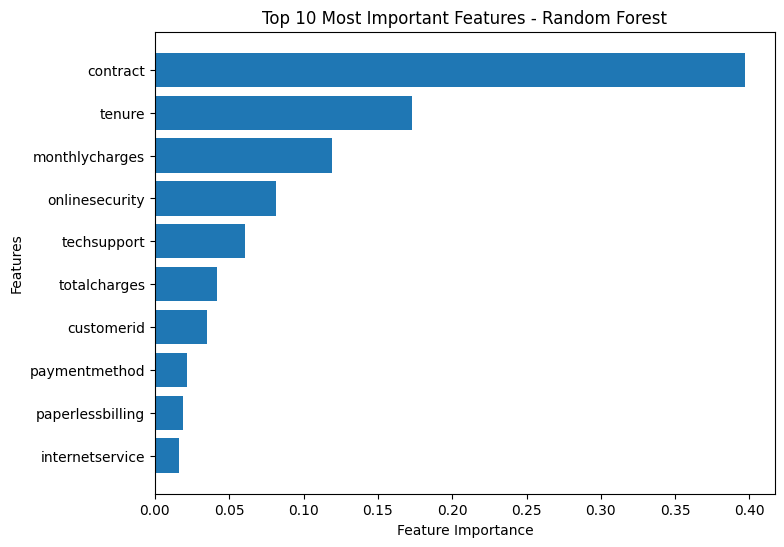

In [91]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [92]:
low_importance = feature_importance[
    feature_importance["Importance"] < 0.01
]

print("Features with Importance < 0.01")
print("="*40)

print(low_importance)

Features with Importance < 0.01
             Feature  Importance
7      multiplelines    0.009661
10      onlinebackup    0.008922
2      seniorcitizen    0.006816
14   streamingmovies    0.004637
4         dependents    0.002926
13       streamingtv    0.000429
6       phoneservice    0.000427
1             gender    0.000333
11  deviceprotection    0.000177
3            partner    0.000007


In [93]:
features_to_remove = low_importance["Feature"].tolist()

print("Potential Features to Remove:")
print(features_to_remove)

Potential Features to Remove:
['multiplelines', 'onlinebackup', 'seniorcitizen', 'streamingmovies', 'dependents', 'streamingtv', 'phoneservice', 'gender', 'deviceprotection', 'partner']


5C — Ensemble Model Creation  

In [94]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [95]:
# Base Models
lr = LogisticRegression(max_iter=1000, random_state=42)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingClassifier(
    random_state=42
)

In [96]:
# Base learners
estimators = [
    ("lr", lr),
    ("rf", rf),
    ("gb", gb)
]

# Meta-model
meta_model = LogisticRegression(max_iter=1000)

# Stacking Classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

In [97]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Stacking Ensemble": stacking_model
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    cv_accuracy = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_accuracy
    ])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [98]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "CV Accuracy"
    ]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy
0,Gradient Boosting,0.7999,0.6608,0.5053,0.5727,0.8425,0.8017
1,Stacking Ensemble,0.7984,0.6541,0.5107,0.5736,0.8434,0.8039
2,Random Forest,0.7935,0.6477,0.4866,0.5557,0.8277,0.7936
3,Logistic Regression,0.7921,0.6302,0.5241,0.5723,0.8377,0.8049


In [99]:
best_model = comparison.iloc[0]

print("="*60)
print("Best Performing Model")
print("="*60)

print(best_model)

Best Performing Model
Model          Gradient Boosting
Accuracy                0.799858
Precision               0.660839
Recall                  0.505348
F1-Score                0.572727
ROC-AUC                 0.842457
CV Accuracy             0.801737
Name: 0, dtype: object


In [100]:
!pip install shap -q

In [101]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize JavaScript for force plots
shap.initjs()

In [104]:
# Create explainer
explainer = shap.TreeExplainer(models[best_model['Model']])

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


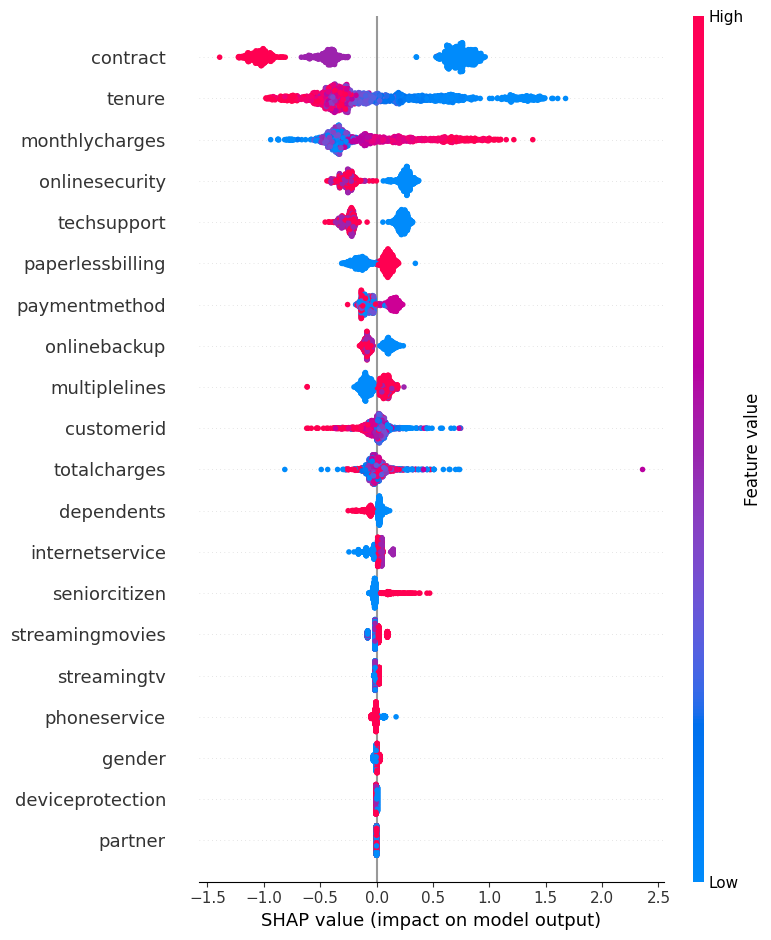

In [106]:
shap.summary_plot(
    shap_values,
    X_test
)

In [108]:
# Select a customer
sample_index = 0

# Display force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

In [111]:
probability = models[best_model['Model']].predict_proba(X_test.iloc[[sample_index]])[0][1]

print(f"Predicted Probability of Churn: {probability:.2%}")

Predicted Probability of Churn: 2.67%


In [117]:
sample_index = 0

# Create DataFrame for one prediction
shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_values[sample_index]
})

# Sort by SHAP value
positive = shap_df.sort_values(by="SHAP Value", ascending=False)
negative = shap_df.sort_values(by="SHAP Value", ascending=True)

print("Top Positive Contributors")
print(positive.head(5))

print("\nTop Negative Contributors")
print(negative.head(5))

Top Positive Contributors
             Feature  SHAP Value
18    monthlycharges    0.671598
16  paperlessbilling    0.079210
7      multiplelines    0.027398
1             gender    0.026912
0         customerid    0.024383

Top Negative Contributors
           Feature  SHAP Value
15        contract   -1.057157
5           tenure   -0.839980
19    totalcharges   -0.255872
12     techsupport   -0.236596
9   onlinesecurity   -0.184438


In [119]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

In [113]:
print(positive.head(5))
print(negative.head(5))

         Feature  SHAP Value
0     customerid    0.002624
1         gender    0.002624
2  seniorcitizen    0.002624
3        partner    0.002624
4     dependents    0.002624
         Feature  SHAP Value
0     customerid    0.002624
1         gender    0.002624
2  seniorcitizen    0.002624
3        partner    0.002624
4     dependents    0.002624


In [114]:
shap.__version__

'0.52.0'

In [115]:
type(shap_values)

numpy.ndarray

In [116]:
np.array(shap_values).shape

(1409, 20)

In [120]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import accuracy_score

In [121]:
# Original Random Forest Model
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [122]:
# Training Accuracy
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

# Overfitting Gap
overfitting_gap = train_accuracy - test_accuracy

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Overfitting Gap   : {overfitting_gap:.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.7935
Overfitting Gap   : 0.2065


In [123]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

Cross Validation Scores:
[0.81810115 0.79680568 0.78970719 0.78527063 0.77797513]

Mean Accuracy : 0.7936
Standard Deviation : 0.0137


In [125]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [126]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [127]:
# Training Accuracy
train_pred_best = best_rf.predict(X_train)
train_accuracy_best = accuracy_score(
    y_train,
    train_pred_best
)

# Testing Accuracy
test_pred_best = best_rf.predict(X_test)
test_accuracy_best = accuracy_score(
    y_test,
    test_pred_best
)

# Overfitting Gap
gap_best = train_accuracy_best - test_accuracy_best

# Cross Validation
cv_best = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Training Accuracy :", train_accuracy_best)
print("Testing Accuracy :", test_accuracy_best)
print("Cross Validation :", cv_best.mean())
print("Overfitting Gap :", gap_best)

Training Accuracy : 0.8837415690450834
Testing Accuracy : 0.7963094393186657
Cross Validation : 0.803512051202441
Overfitting Gap : 0.08743212972641767


In [128]:
comparison = pd.DataFrame({
    "Metric":[
        "Training Accuracy",
        "Testing Accuracy",
        "CV Accuracy",
        "Overfitting Gap"
    ],

    "Before Tuning":[
        train_accuracy,
        test_accuracy,
        cv_scores.mean(),
        overfitting_gap
    ],

    "After Tuning":[
        train_accuracy_best,
        test_accuracy_best,
        cv_best.mean(),
        gap_best
    ]
})

comparison.round(4)

,Metric,Before Tuning,After Tuning
0,Training Accuracy,1.0000,0.8837
1,Testing Accuracy,0.7935,0.7963
2,CV Accuracy,0.7936,0.8035
3,Overfitting Gap,0.2065,0.0874


In [129]:
print("="*60)

if gap_best < overfitting_gap:
    print("The tuned Random Forest model generalises better than the original model.")
else:
    print("The original Random Forest model performs similarly or better.")

print("="*60)

The tuned Random Forest model generalises better than the original model.


In [130]:
# Predict class labels
y_pred = best_rf.predict(X_test)

# Predict probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [131]:
predicted_churn = ["Yes" if pred == 1 else "No" for pred in y_pred]

actual_churn = ["Yes" if actual == 1 else "No" for actual in y_test]

In [132]:
prediction_df = pd.DataFrame({
    "Actual Churn": actual_churn,
    "Predicted Churn": predicted_churn,
    "Churn Probability": y_prob
})

prediction_df["Churn Probability"] = prediction_df["Churn Probability"].round(4)

prediction_df

,Actual Churn,Predicted Churn,Churn Probability
0,No,No,0.0088
1,No,Yes,0.6565
2,No,No,0.1108
3,No,No,0.4213
4,No,No,0.0322
...,...,...,...
1404,No,No,0.0615
1405,No,No,0.0013
1406,No,No,0.0804
1407,No,No,0.0571


In [133]:
prediction_df.head(10)

,Actual Churn,Predicted Churn,Churn Probability
0,No,No,0.0088
1,No,Yes,0.6565
2,No,No,0.1108
3,No,No,0.4213
4,No,No,0.0322
5,No,Yes,0.5819
6,No,No,0.3975
7,No,No,0.1104
8,No,No,0.0041
9,Yes,No,0.3414


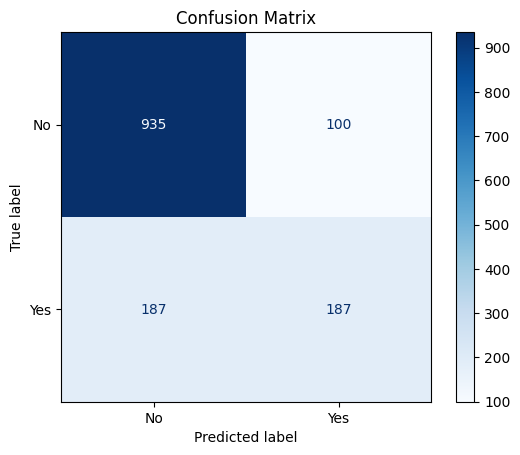

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [135]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.83      0.90      0.87      1035
         Yes       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [136]:
prediction_df.sort_values(
    by="Churn Probability",
    ascending=False
).head(10)

,Actual Churn,Predicted Churn,Churn Probability
1090,Yes,Yes,0.8836
629,No,Yes,0.8751
1109,Yes,Yes,0.8708
341,Yes,Yes,0.8609
771,Yes,Yes,0.8555
618,Yes,Yes,0.8539
710,Yes,Yes,0.8535
740,Yes,Yes,0.8481
435,Yes,Yes,0.8472
1221,Yes,Yes,0.8465
